<a href="https://colab.research.google.com/github/gtsagkatakis/Data-Science-and-Applications-2026/blob/main/Multimodal_Universe_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

data = torch.load("multimodal_universe_processed.pt", map_location="cpu")
spectra = data["spectra"].float()   # [N, L]
Z = data["targets"].float()         # [N]

print(spectra.shape, Z.shape)

x = spectra.mean(dim=1)   # [N]

torch.Size([25, 3862]) torch.Size([25])


In [2]:
# Design matrix [x, 1]
X = torch.stack([x, torch.ones_like(x)], dim=1)   # [N, 2]

# Solve min ||X theta - Z||^2
theta = torch.linalg.lstsq(X, Z).solution         # [2]
a, b = theta[0].item(), theta[1].item()

print(f"Fitted line: Z ≈ {a:.6f} * x + {b:.6f}")

Fitted line: Z ≈ -0.026951 * x + 0.617894


RMSE: 0.5515


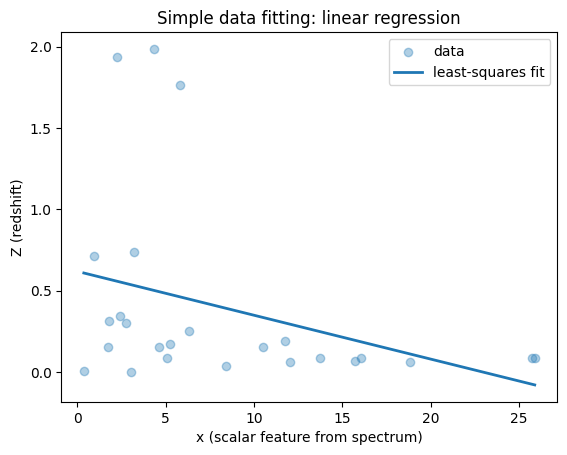

In [3]:
Z_pred = X @ theta
rmse = torch.sqrt(torch.mean((Z_pred - Z)**2)).item()

print(f"RMSE: {rmse:.4f}")

plt.figure()
plt.scatter(x.numpy(), Z.numpy(), alpha=0.35, label="data")
# sort for a clean line plot
idx = torch.argsort(x)
plt.plot(x[idx].numpy(), Z_pred[idx].numpy(), linewidth=2, label="least-squares fit")
plt.xlabel("x (scalar feature from spectrum)")
plt.ylabel("Z (redshift)")
plt.title("Simple data fitting: linear regression")
plt.legend()
plt.show()

Degree-2 polynomial RMSE: 0.5498


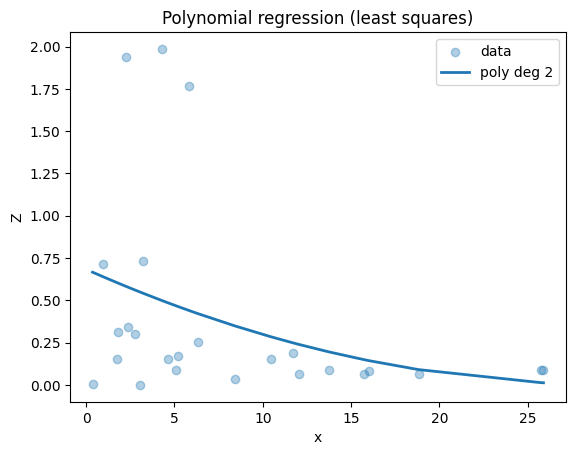

In [4]:
degree = 2  # try 1,2,3,5
X_poly = torch.stack([x**k for k in range(degree, -1, -1)], dim=1)  # [x^d, ..., x, 1]

theta_poly = torch.linalg.lstsq(X_poly, Z).solution
Zp = X_poly @ theta_poly
rmse_poly = torch.sqrt(torch.mean((Zp - Z)**2)).item()

print(f"Degree-{degree} polynomial RMSE: {rmse_poly:.4f}")

plt.figure()
plt.scatter(x.numpy(), Z.numpy(), alpha=0.35, label="data")
idx = torch.argsort(x)
plt.plot(x[idx].numpy(), Zp[idx].numpy(), linewidth=2, label=f"poly deg {degree}")
plt.xlabel("x")
plt.ylabel("Z")
plt.title("Polynomial regression (least squares)")
plt.legend()
plt.show()